1. Stacked (Deep) LSTM
2. Bidirectional LSTM
3. MultiLayer LSTM
4. Stateful LSTM
5. Residual LSTM

In [1]:
pip install tensorflow-macos==2.15.0

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,LSTM,Bidirectional,Input,Add
from tensorflow.keras.optimizers import Adam

In [8]:
import pandas as pd
input_path ="../Week7/HistoricalData_1772703629758.csv"
df = pd.read_csv(input_path)  
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
# df = df[['Close']]  
print(df.head(10))
print(df.dtypes)

           Close/Last    Volume      Open     High       Low
Date                                                        
2026-03-04    $262.52  39803120   $264.65  $266.15   $261.42
2026-03-03    $263.75  38568920   $263.48  $265.56   $260.13
2026-03-02    $264.72  41827950   $262.41  $266.53   $260.20
2026-02-27    $264.18  72366510   $272.81  $272.81   $262.89
2026-02-26    $272.95  32345110  $274.945  $276.11  $270.795
2026-02-25    $274.23  33714340   $271.78  $274.94   $271.05
2026-02-24    $272.14  47014620   $267.86  $274.89   $267.71
2026-02-23    $266.18  37308160   $263.49  $269.43  $263.381
2026-02-20    $264.58  42070500   $258.97  $264.75   $258.16
2026-02-19    $260.58  30845290   $262.60  $264.48   $260.05
Close/Last    object
Volume         int64
Open          object
High          object
Low           object
dtype: object


Preprocessing

In [9]:
# Clean price columns: remove $, convert to float
price_cols = ['Close/Last', 'Open', 'High', 'Low']

for col in price_cols:
    # Remove $ and convert to float
    df[col] = df[col].str.replace('$', '').str.replace(',', '').astype(float)

# For RNN modeling, use float32 (more efficient, sufficient precision)
price_cols = ['Close/Last', 'Open', 'High', 'Low']
for col in price_cols:
    df[col] = df[col].astype(np.float32)


# Rename the column to 'Close'
df = df.rename(columns={'Close/Last': 'Close'})

print(df.head())
print(df.dtypes)

                 Close    Volume        Open        High         Low
Date                                                                
2026-03-04  262.519989  39803120  264.649994  266.149994  261.420013
2026-03-03  263.750000  38568920  263.480011  265.559998  260.130005
2026-03-02  264.720001  41827950  262.410004  266.529999  260.200012
2026-02-27  264.179993  72366510  272.809998  272.809998  262.890015
2026-02-26  272.950012  32345110  274.945007  276.109985  270.795013
Close     float32
Volume      int64
Open      float32
High      float32
Low       float32
dtype: object


In [10]:
input_df=df[['Close']]
input_df = input_df.sort_index(ascending=True)
input_df.head(10)

,Close
Date,
2021-03-05,121.419998
2021-03-08,116.360001
2021-03-09,121.084999
2021-03-10,119.980003
2021-03-11,121.959999
2021-03-12,121.029999
2021-03-15,123.989998
2021-03-16,125.570000
2021-03-17,124.760002


In [13]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(input_df)
##this is ideally not correct - transform should be fit only on train data 
scaled_data


def create_sequences(data , window =30) :
    X,y = [] ,[]
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X) , np.array(y)

window_size =30
X,y = create_sequences(scaled_data,window=window_size)
    

In [14]:
X.shape,y.shape

((1225, 30, 1), (1225, 1))

In [17]:
X_train , X_test , y_train , y_test =train_test_split(X,y, test_size =0.2, shuffle=False)

In [18]:
X_train.shape,X_test.shape

((980, 30, 1), (245, 30, 1))

Visualize the Data

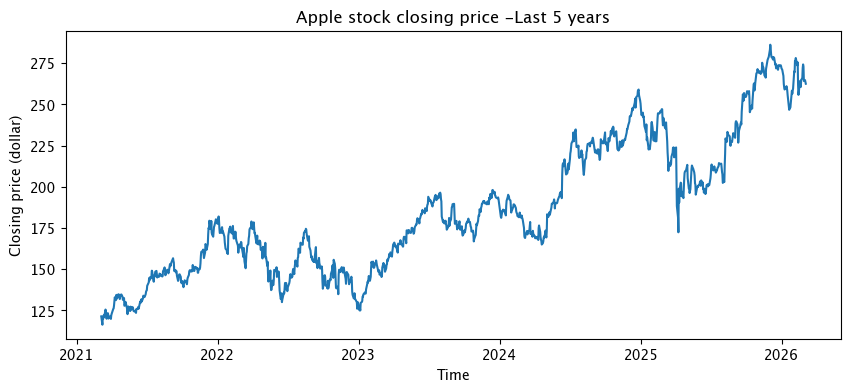

In [19]:
plt.figure(figsize =(10,4))
plt.plot(input_df['Close'])
plt.title('Apple stock closing price -Last 5 years')
plt.xlabel('Time')
plt.ylabel('Closing price (dollar)')
plt.show()

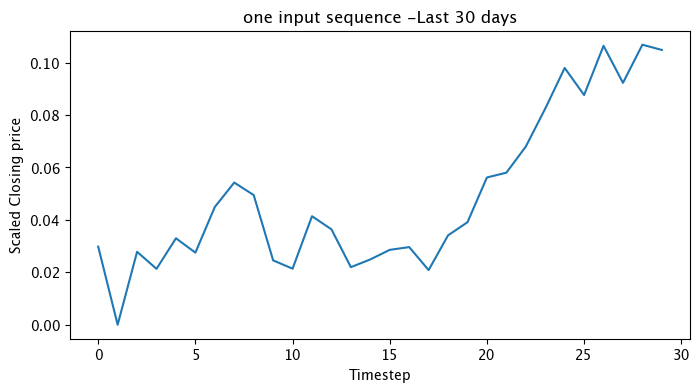

In [20]:
plt.figure(figsize =(8,4))
plt.plot(X[0])
plt.title('one input sequence -Last 30 days')
plt.xlabel('Timestep')
plt.ylabel('Scaled Closing price')
plt.show()

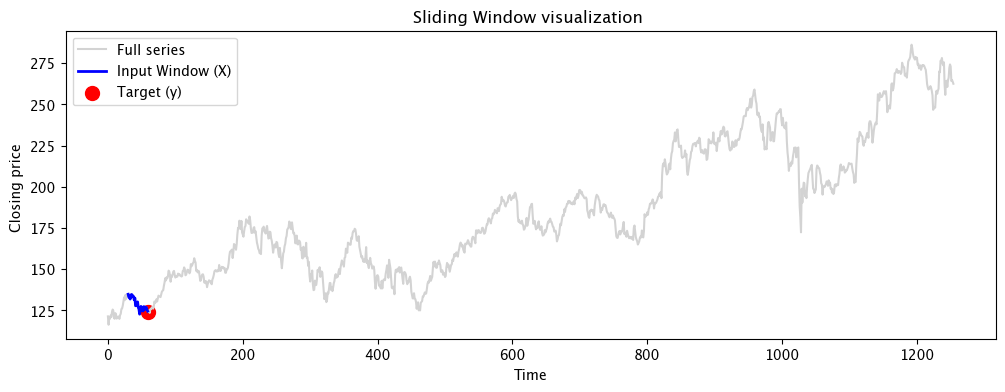

In [22]:
i=60

window_size=30

plt.figure(figsize =(12,4))
##full series 
plt.plot(input_df['Close'].values , color='lightgray',label ='Full series')
##sliding window (X)
plt.plot(range(i-window_size,i),input_df['Close'].values[i-window_size:i], color='blue',\
         linewidth=2,label ='Input Window (X)')

# target value (y)
plt.scatter(i,input_df['Close'].values[i],color ='red',s=100 , label ='Target (y)')
plt.title('Sliding Window visualization ')
plt.xlabel('Time')
plt.ylabel('Closing price ')
plt.legend()
plt.show()

Utility Function

In [23]:
def compile_and_train(model, name, epochs=10,batch_size =32):
    model.compile(optimizer='adam',loss='mse')
    history = model.fit(X_train ,y_train , epochs=epochs, batch_size = batch_size ,verbose=1)
    print(f"{name}  trained")
    return history

Stacked LSTM

In [25]:
window_size=30 
batch_size =32
epochs=10
stacked_lstm = Sequential([Input(shape=(window_size,1)),
                          LSTM(50,return_sequences=True),
                          LSTM(50),
                          Dense(1)])
stacked_lstm.summary()
hist_stacked = compile_and_train(stacked_lstm,"Stacked LSTM")

##parameters for rnn = ip features *hidden units + hidden units *hidden units + bias(hidden units)
#for lstm -4 gates parameters *4 

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 30, 50)            10400     
                                                                 
 lstm_3 (LSTM)               (None, 50)                20200     
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 30651 (119.73 KB)
Trainable params: 30651 (119.73 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
31/31 [==============================] - 1s 9ms/step - loss: 0.0163
Epoch 2/10
31/31 [==============================] - 0s 10ms/step - loss: 0.0019
Epoch 3/10
31/31 [==============================] - 0s 9ms/step - loss: 0.0015
Epoch 4/10
31/31 [========================

In [26]:
prediction =stacked_lstm(X_test)
prediction =scaler.inverse_transform(prediction)

In [31]:
actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
    print(f" Predicted : {prediction[i][0]:.2f} , Actual :{actual[i][0]:.2f} ")

 Predicted : 231.69 , Actual :209.68 
 Predicted : 227.96 , Actual :213.49 
 Predicted : 224.33 , Actual :214.00 
 Predicted : 221.05 , Actual :212.69 
 Predicted : 218.14 , Actual :215.24 
 Predicted : 215.88 , Actual :214.10 
 Predicted : 214.13 , Actual :218.27 
 Predicted : 213.16 , Actual :220.73 
 Predicted : 212.97 , Actual :223.75 
 Predicted : 213.54 , Actual :221.53 
 Predicted : 214.41 , Actual :223.85 
 Predicted : 215.61 , Actual :217.90 
 Predicted : 216.47 , Actual :222.13 
 Predicted : 217.42 , Actual :223.19 
 Predicted : 218.42 , Actual :223.89 
 Predicted : 219.43 , Actual :203.19 
 Predicted : 218.76 , Actual :188.38 
 Predicted : 216.01 , Actual :181.46 
 Predicted : 211.61 , Actual :172.42 
 Predicted : 205.78 , Actual :198.85 
 Predicted : 201.41 , Actual :190.42 
 Predicted : 197.55 , Actual :198.15 
 Predicted : 194.92 , Actual :202.52 
 Predicted : 193.59 , Actual :202.14 
 Predicted : 193.18 , Actual :194.27 
 Predicted : 192.86 , Actual :196.98 
 Predicted :

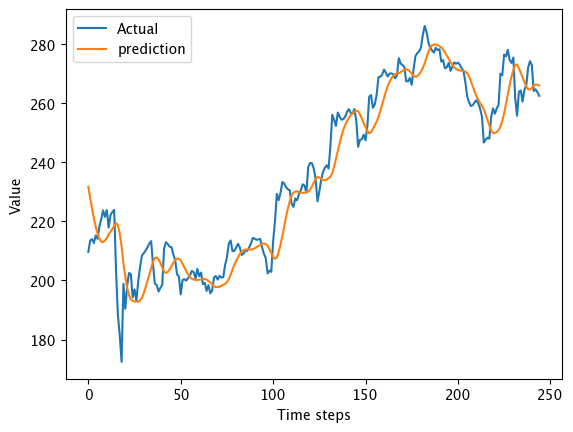

In [32]:
plt.figure()
plt.plot(actual , label ="Actual")
plt.plot(prediction , label ="prediction")
plt.xlabel("Time steps")
plt.ylabel("Value")
plt.legend()
plt.show()

Bidirectional LSTM

In [39]:
bilstm = Sequential([Input(shape=(window_size,1)),
                    Bidirectional(LSTM(50)),
                    Dense(1)])

bilstm.summary()

hist_bilstm = compile_and_train(bilstm , "BiDirectional LSTM")

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_2 (Bidirecti  (None, 100)               20800     
 onal)                                                           
                                                                 
 dense_5 (Dense)             (None, 1)                 101       
                                                                 
Total params: 20901 (81.64 KB)
Trainable params: 20901 (81.64 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
31/31 [==============================] - 1s 10ms/step - loss: 0.0244
Epoch 2/10
31/31 [==============================] - 0s 11ms/step - loss: 0.0042
Epoch 3/10
31/31 [==============================] - 0s 11ms/step - loss: 0.0028
Epoch 4/10
31/31 [==============================] - 0s 11ms/step - loss: 0.0025
Epoch 5/10
31/31 [==========

In [40]:
prediction =bilstm(X_test)
prediction =scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
    print(f" Predicted : {prediction[i][0]:.2f} , Actual :{actual[i][0]:.2f} ")

 Predicted : 233.45 , Actual :209.68 
 Predicted : 228.74 , Actual :213.49 
 Predicted : 224.21 , Actual :214.00 
 Predicted : 220.21 , Actual :212.69 
 Predicted : 217.05 , Actual :215.24 
 Predicted : 214.53 , Actual :214.10 
 Predicted : 212.78 , Actual :218.27 
 Predicted : 212.05 , Actual :220.73 
 Predicted : 212.59 , Actual :223.75 
 Predicted : 214.11 , Actual :221.53 
 Predicted : 215.97 , Actual :223.85 
 Predicted : 218.16 , Actual :217.90 
 Predicted : 220.03 , Actual :222.13 
 Predicted : 221.91 , Actual :223.19 
 Predicted : 223.87 , Actual :223.89 
 Predicted : 225.78 , Actual :203.19 
 Predicted : 226.04 , Actual :188.38 
 Predicted : 224.04 , Actual :181.46 
 Predicted : 220.01 , Actual :172.42 
 Predicted : 214.22 , Actual :198.85 
 Predicted : 209.52 , Actual :190.42 
 Predicted : 205.17 , Actual :198.15 
 Predicted : 201.51 , Actual :202.52 
 Predicted : 199.07 , Actual :202.14 
 Predicted : 197.54 , Actual :194.27 
 Predicted : 196.18 , Actual :196.98 
 Predicted :

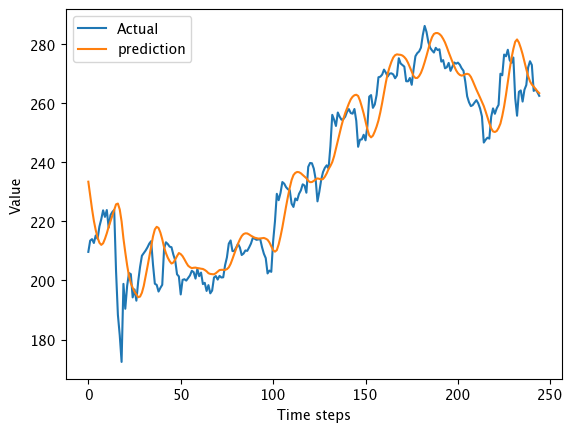

In [41]:
plt.figure()
plt.plot(actual , label ="Actual")
plt.plot(prediction , label ="prediction")
plt.xlabel("Time steps")
plt.ylabel("Value")
plt.legend()
plt.show()

Multi Layer LSTM

In [42]:
multilayer_lstm = Sequential([Input(shape=(window_size,1)),
                    LSTM(100,return_sequences=True),
                    LSTM(50,return_sequences=True),
                    LSTM(25),
                    Dense(1)])

multilayer_lstm.summary()

hist_multilayer = compile_and_train(multilayer_lstm , "MultiLayer LSTM")

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_10 (LSTM)              (None, 30, 100)           40800     
                                                                 
 lstm_11 (LSTM)              (None, 30, 50)            30200     
                                                                 
 lstm_12 (LSTM)              (None, 25)                7600      
                                                                 
 dense_6 (Dense)             (None, 1)                 26        
                                                                 
Total params: 78626 (307.13 KB)
Trainable params: 78626 (307.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
31/31 [==============================] - 2s 11ms/step - loss: 0.0246
Epoch 2/10
31/31 [==============================] - 0s 11ms/step - l

In [43]:
prediction =multilayer_lstm(X_test)
prediction =scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
    print(f" Predicted : {prediction[i][0]:.2f} , Actual :{actual[i][0]:.2f} ")

 Predicted : 240.55 , Actual :209.68 
 Predicted : 238.15 , Actual :213.49 
 Predicted : 235.41 , Actual :214.00 
 Predicted : 232.52 , Actual :212.69 
 Predicted : 229.60 , Actual :215.24 
 Predicted : 226.86 , Actual :214.10 
 Predicted : 224.38 , Actual :218.27 
 Predicted : 222.35 , Actual :220.73 
 Predicted : 220.86 , Actual :223.75 
 Predicted : 220.01 , Actual :221.53 
 Predicted : 219.70 , Actual :223.85 
 Predicted : 219.90 , Actual :217.90 
 Predicted : 220.35 , Actual :222.13 
 Predicted : 221.01 , Actual :223.19 
 Predicted : 221.82 , Actual :223.89 
 Predicted : 222.71 , Actual :203.19 
 Predicted : 223.16 , Actual :188.38 
 Predicted : 222.67 , Actual :181.46 
 Predicted : 221.01 , Actual :172.42 
 Predicted : 218.06 , Actual :198.85 
 Predicted : 214.62 , Actual :190.42 
 Predicted : 210.90 , Actual :198.15 
 Predicted : 207.36 , Actual :202.52 
 Predicted : 204.34 , Actual :202.14 
 Predicted : 202.01 , Actual :194.27 
 Predicted : 200.25 , Actual :196.98 
 Predicted :

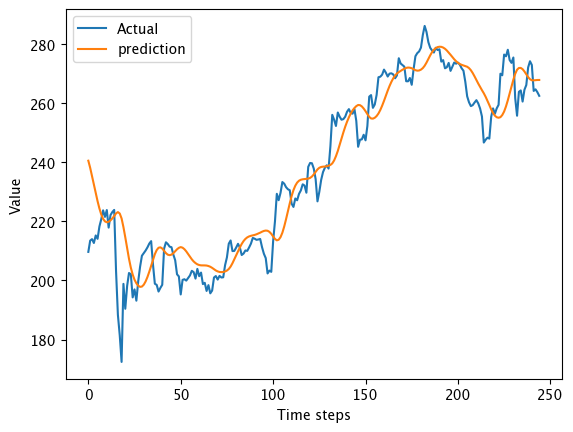

In [44]:
plt.figure()
plt.plot(actual , label ="Actual")
plt.plot(prediction , label ="prediction")
plt.xlabel("Time steps")
plt.ylabel("Value")
plt.legend()
plt.show()

Stateful LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM , Dense , Input

batch_size= 32

stateful_lstm = Sequential([Input(batch_shape=(batch_size,window_size,1)),
                    LSTM(50,stateful=True),
                    Dense(1)])

stateful_lstm.compile(optimizer='adam',loss='mse')
stateful_lstm.summary()

train_len = len(X_train) - (len(X_train)%batch_size)
print(train_len)
X_train_s = X_train[:train_len]
y_train_s = y_train[:train_len]

stateful_losses =[]

for epoch in range(10):
    history = stateful_lstm.fit(X_train_s,y_train_s,epochs=1,batch_size=batch_size,shuffle=False,verbose=1)
    stateful_losses.append(history.history['loss'][0])

    for layer in stateful_lstm.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()
            
    print('stateful LSTM trained successfully')

REsidual LSTM

In [50]:
inputs = Input(shape = (window_size,1))

x =LSTM(50 , return_sequences= True)(inputs)
x =LSTM(50)(x)

shortcut = LSTM(50)(inputs)

output = Add()([x,shortcut])
output = Dense(1)(output)

residual_lstm = tf.keras.Model(inputs , output)
residual_lstm.summary()

hist_residual =compile_and_train(residual_lstm , "Residual LSTM")

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_13 (InputLayer)       [(None, 30, 1)]              0         []                            
                                                                                                  
 lstm_18 (LSTM)              (None, 30, 50)               10400     ['input_13[0][0]']            
                                                                                                  
 lstm_19 (LSTM)              (None, 50)                   20200     ['lstm_18[0][0]']             
                                                                                                  
 lstm_20 (LSTM)              (None, 50)                   10400     ['input_13[0][0]']            
                                                                                              

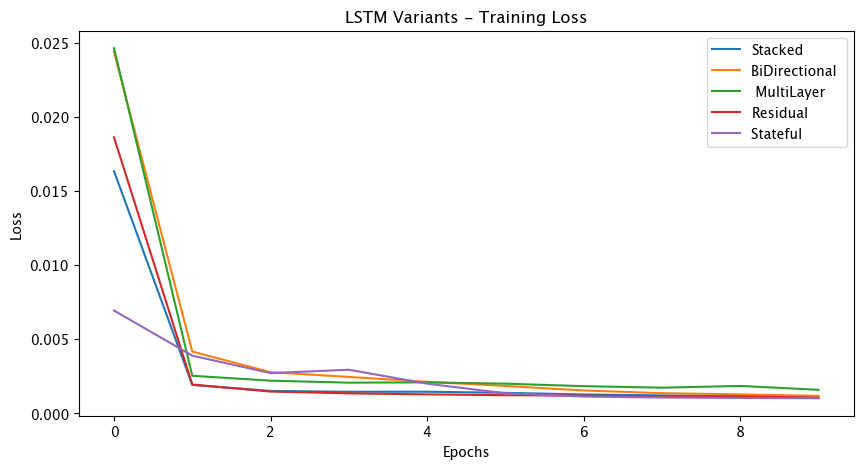

In [51]:
plt.figure(figsize =(10,5))
plt.plot(hist_stacked.history['loss'], label='Stacked')
plt.plot(hist_bilstm.history['loss'], label='BiDirectional ')
plt.plot(hist_multilayer.history['loss'], label=' MultiLayer')
plt.plot(hist_residual.history['loss'], label='Residual')
plt.plot(stateful_losses, label='Stateful ')

plt.title('LSTM Variants - Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()